# Chapter 12 — Neural networks that write like Shakespeare

> *Grokking Deep Learning* — Andrew W. Trask

Chapter ini memperluas **word embeddings** dari Chapter 11 menjadi **sentence embeddings** yang dapat menangani sequence dengan panjang berbeda. Fokus utamanya adalah **Recurrent Neural Networks (RNNs)**, recurrent/transition matrix, forward propagation, backpropagation through arbitrary-length sequences, dan language modeling.

## Learning Objectives

Setelah menyelesaikan chapter ini, kita diharapkan dapat:

1. Menjelaskan masalah **variable-length sequences**.
2. Memahami mengapa concatenation kurang cocok untuk sentence representation.
3. Memahami kelebihan dan keterbatasan **averaged word vectors**.
4. Menjelaskan bagaimana transition matrix memungkinkan informasi urutan kata dipertahankan.
5. Memahami konsep **recurrent layer**.
6. Menjelaskan forward propagation pada sequence dengan panjang arbitrer.
7. Memahami backpropagation pada recurrent computation.
8. Memahami hubungan training dengan **perplexity**.
9. Menginterpretasikan prediksi next-word dari language model sederhana.

## Chapter Roadmap

**Variable-length sequence → Sentence vector → Average word vectors → Limitations of Bag-of-Words → Identity matrix → Learnable transition matrix → Next-word prediction → Forward propagation → Backpropagation → Weight update → Perplexity**

Buku secara eksplisit menghubungkan Chapter 12 dengan Chapter 11: word embedding pada Chapter 11 menyimpan informasi mengenai satu kata, sedangkan chapter ini memperluasnya untuk menyimpan informasi mengenai **phrase dan sentence dengan panjang berbeda**.

## The Challenge of Arbitrary Length

Jika setiap word memiliki embedding, cara paling sederhana untuk membentuk sentence vector adalah dengan **concatenating/stacking** seluruh word vectors.

Masalahnya: panjang sentence berbeda menghasilkan vector dengan panjang berbeda.

Contoh:
- `the cat sat`
- `the cat sat still`

Keduanya sangat mirip, tetapi concatenation menghasilkan ukuran vector berbeda sehingga perbandingan menjadi tidak praktis. Buku menekankan bahwa sentence representation yang baik harus menghasilkan vector yang dapat dibandingkan.

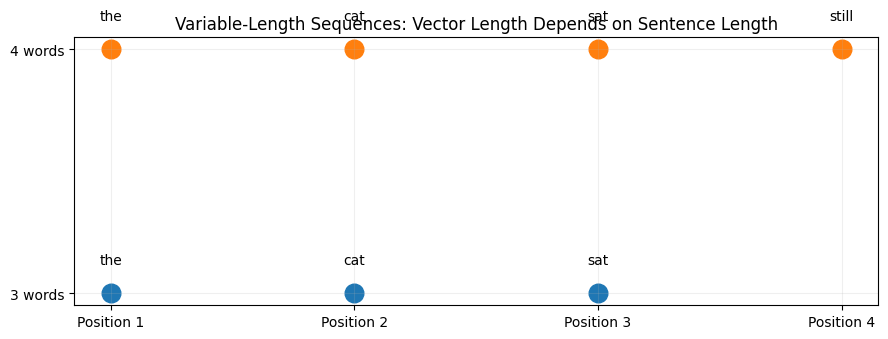

In [1]:
import matplotlib.pyplot as plt
import numpy as np
sentences = {
    "the cat sat": 3,
    "the cat sat still": 4
}

plt.figure(figsize=(9, 3.5))
for y, (sentence, length) in enumerate(sentences.items()):
    plt.scatter(range(length), [y]*length, s=180)
    for i, word in enumerate(sentence.split()):
        plt.text(i, y+0.12, word, ha="center", fontsize=10)
plt.yticks([0,1], ["3 words", "4 words"])
plt.xticks(range(4), ["Position 1","Position 2","Position 3","Position 4"])
plt.title("Variable-Length Sequences: Vector Length Depends on Sentence Length")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Do Comparisons Really Matter?

Ya. Neural network hanya dapat menggunakan informasi yang tersedia dalam vector.

Jika dua sentence yang maknanya mirip menghasilkan vector yang sangat berbeda, network akan kesulitan menemukan correlation yang berguna. Sebaliknya, sentence yang mirip sebaiknya menghasilkan representation yang juga relatif mirip.

Karena itu, chapter ini mencari cara membangun **fixed-length sentence vector** yang tetap membawa informasi penting dari sequence.

## The Surprising Power of Averaged Word Vectors

Pendekatan berikutnya adalah mengambil **average** dari word embeddings.

Keuntungannya:
- setiap sentence menghasilkan vector dengan ukuran yang sama;
- tidak membutuhkan alignment;
- sentence dengan banyak kata yang sama cenderung menghasilkan vector yang mirip.

Buku memberi contoh bahwa `the cat sat` dan `the cat sat still` akan menghasilkan vector yang mirip. Bahkan sentence dengan kata yang berbeda, seperti `a dog walked`, dapat menjadi dekat jika word embeddings-nya memiliki hubungan yang serupa.

In [2]:
import numpy as np

# Contoh embedding sederhana untuk menjelaskan average.
word_vectors = {
    "the": np.array([1.0, 0.0, 0.0]),
    "cat": np.array([0.0, 1.0, 0.0]),
    "sat": np.array([0.0, 0.0, 1.0]),
    "still": np.array([0.2, 0.2, 0.2])
}

def average_sentence(sentence):
    return np.mean([word_vectors[w] for w in sentence.split()], axis=0)

for sentence in ["the cat sat", "the cat sat still"]:
    print(sentence, "->", average_sentence(sentence))

the cat sat -> [0.33333333 0.33333333 0.33333333]
the cat sat still -> [0.3 0.3 0.3]


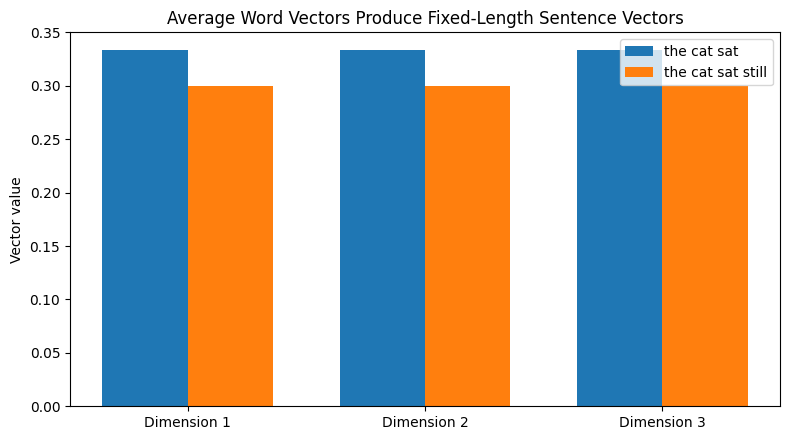

In [3]:
sent_a = average_sentence("the cat sat")
sent_b = average_sentence("the cat sat still")

plt.figure(figsize=(8, 4.5))
x = np.arange(3)
width = 0.36
plt.bar(x-width/2, sent_a, width, label="the cat sat")
plt.bar(x+width/2, sent_b, width, label="the cat sat still")
plt.xticks(x, ["Dimension 1","Dimension 2","Dimension 3"])
plt.ylabel("Vector value")
plt.title("Average Word Vectors Produce Fixed-Length Sentence Vectors")
plt.legend()
plt.tight_layout()
plt.show()

### Keterbatasan Averaging

Average word vectors memang menghasilkan ukuran vector yang konsisten, tetapi ada informasi yang hilang: **word order**.

Misalnya:

`Red Sox defeat Yankees`

dan

`Yankees defeat Red Sox`

dapat menghasilkan vector yang sama jika kata-kata yang digunakan sama, walaupun maknanya berbeda. Buku menggunakan masalah ini sebagai motivasi untuk mempelajari transition matrix yang dapat membuat representasi bergantung pada urutan kata.

In [4]:
sentence_1 = ["Red", "Sox", "defeat", "Yankees"]
sentence_2 = ["Yankees", "defeat", "Red", "Sox"]

# Average bersifat permutation-invariant.
demo_vectors = {w: np.arange(3) + i for i, w in enumerate(
    ["Red", "Sox", "defeat", "Yankees"]
)}

avg1 = np.mean([demo_vectors[w] for w in sentence_1], axis=0)
avg2 = np.mean([demo_vectors[w] for w in sentence_2], axis=0)

print("Sentence 1 average:", avg1)
print("Sentence 2 average:", avg2)
print("Same representation:", np.allclose(avg1, avg2))

Sentence 1 average: [1.5 2.5 3.5]
Sentence 2 average: [1.5 2.5 3.5]
Same representation: True


## Using Identity Matrices to Sum Word Embeddings

Buku memperkenalkan **identity matrix** sebagai teaching tool.

Identity matrix memiliki `1` pada diagonal utama dan `0` di tempat lain. Jika sebuah vector dikalikan dengan identity matrix, vector tersebut tidak berubah.

Jadi:

`vector × Identity = vector`

Dengan menyisipkan identity matrix di antara word embeddings, proses akhirnya tetap sama dengan summing embeddings. Tetapi struktur ini penting karena identity matrix nantinya dapat diganti dengan **learnable transition matrix**.

In [5]:
identity = np.eye(3)
v = np.array([3., 5., 7.])

result = v.dot(identity)

print("v       =", v)
print("identity =\n", identity)
print("v × I   =", result)

v       = [3. 5. 7.]
identity =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
v × I   = [3. 5. 7.]


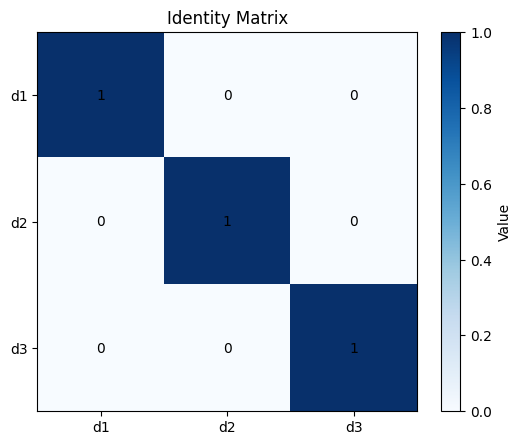

In [6]:
plt.figure(figsize=(5.5, 4.5))
plt.imshow(identity, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(3), ["d1","d2","d3"])
plt.yticks(range(3), ["d1","d2","d3"])
plt.title("Identity Matrix")
for r in range(3):
    for c in range(3):
        plt.text(c, r, int(identity[r,c]), ha="center", va="center")
plt.colorbar(label="Value")
plt.tight_layout()
plt.show()

## Learning the Transition Matrices

Identity matrix tidak mengubah vector sehingga belum membawa informasi tentang urutan.

Solusinya adalah membiarkan matrix tersebut **learn**.

Jika transition matrix menjadi `R`, maka:

`previous_state × R + current_word_embedding`

menghasilkan state baru.

Karena matrix yang sama digunakan berulang pada setiap transition, logic yang dipelajari pada satu step dapat digunakan kembali pada step berikutnya. Ini adalah inti dari recurrent computation yang diperkenalkan chapter.

In [7]:
# Perbandingan identity vs learned transition matrix.
v = np.array([1., 2., 3.])
identity = np.eye(3)
transition = np.array([
    [1.0, 0.2, 0.0],
    [0.0, 0.8, 0.1],
    [0.1, 0.0, 1.0]
])

print("Identity result:", v.dot(identity))
print("Transition result:", v.dot(transition))

Identity result: [1. 2. 3.]
Transition result: [1.3 1.8 3.2]


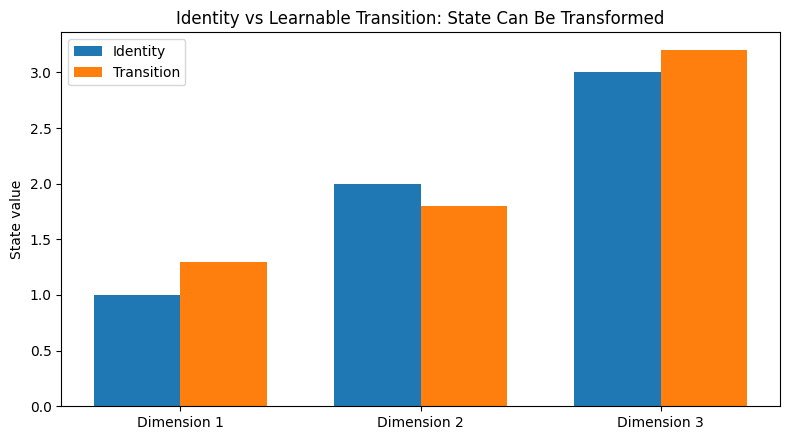

In [8]:
plt.figure(figsize=(8, 4.5))
x = np.arange(3)
before = v.dot(identity)
after = v.dot(transition)

plt.bar(x-0.18, before, 0.36, label="Identity")
plt.bar(x+0.18, after, 0.36, label="Transition")
plt.xticks(x, ["Dimension 1","Dimension 2","Dimension 3"])
plt.ylabel("State value")
plt.title("Identity vs Learnable Transition: State Can Be Transformed")
plt.legend()
plt.tight_layout()
plt.show()

## Learning to Create Useful Sentence Vectors

Buku tidak sekadar ingin menyimpan sequence. Sentence vector harus **berguna untuk prediction**.

Task yang dipilih adalah:

**given previous words → predict the next word**

Contoh:

`["This", "movie", "was"] → ["great"]`

Untuk contoh lain:

`"Red Sox defeat" → "Yankees"`

Network membuat sentence embedding dari kata-kata yang sudah dilihat, lalu menggunakan embedding tersebut untuk memprediksi kata berikutnya.

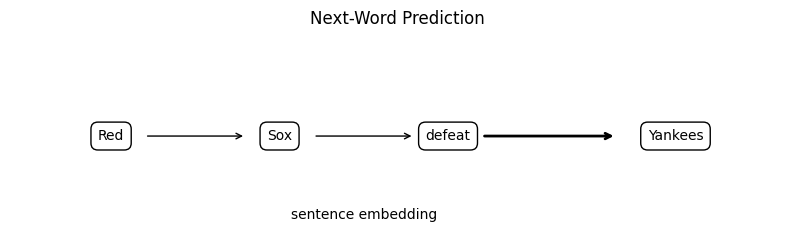

In [9]:
sequence = ["Red", "Sox", "defeat"]
target = "Yankees"

plt.figure(figsize=(10, 2.7))
for i, word in enumerate(sequence):
    plt.text(i, 0.5, word, ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.5", fill=False))
    if i < len(sequence)-1:
        plt.annotate("", xy=(i+0.8,0.5), xytext=(i+0.2,0.5),
                     arrowprops=dict(arrowstyle="->"))
plt.annotate("", xy=(3.0,0.5), xytext=(2.2,0.5),
             arrowprops=dict(arrowstyle="->", lw=2))
plt.text(3.35, 0.5, target, ha="center", va="center",
         bbox=dict(boxstyle="round,pad=0.5", fill=False))
plt.text(1.5, 0.1, "sentence embedding", ha="center")
plt.xlim(-0.6, 4)
plt.ylim(0, 1)
plt.axis("off")
plt.title("Next-Word Prediction")
plt.show()

## Forward Propagation in Python

Source menggunakan toy vocabulary berisi **9 words**, embedding berdimensi `3`, identity matrix sebagai initial transition matrix, dan `sent2output` untuk memprediksi vocabulary berikutnya.

Dengan semua word vectors masih `0`, prediction awal menjadi uniform:

`[0.11111111, ..., 0.11111111]`

untuk 9 vocabulary words.

In [10]:
import numpy as np

def softmax(x_):
    x = np.atleast_2d(x_)
    temp = np.exp(x)
    return temp / np.sum(temp, axis=1, keepdims=True)

word_vects = {}
for word in ["yankees","bears","braves","red","sox","lose","defeat","beat","tie"]:
    word_vects[word] = np.array([[0.,0.,0.]])

np.random.seed(1)
sent2output = np.random.rand(3, len(word_vects))
identity = np.eye(3)

layer_0 = word_vects["red"]
layer_1 = layer_0.dot(identity) + word_vects["sox"]
layer_2 = layer_1.dot(identity) + word_vects["defeat"]
pred = softmax(layer_2.dot(sent2output))

print(pred)
print("Prediction sum:", pred.sum())

[[0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
  0.11111111 0.11111111 0.11111111]]
Prediction sum: 1.0


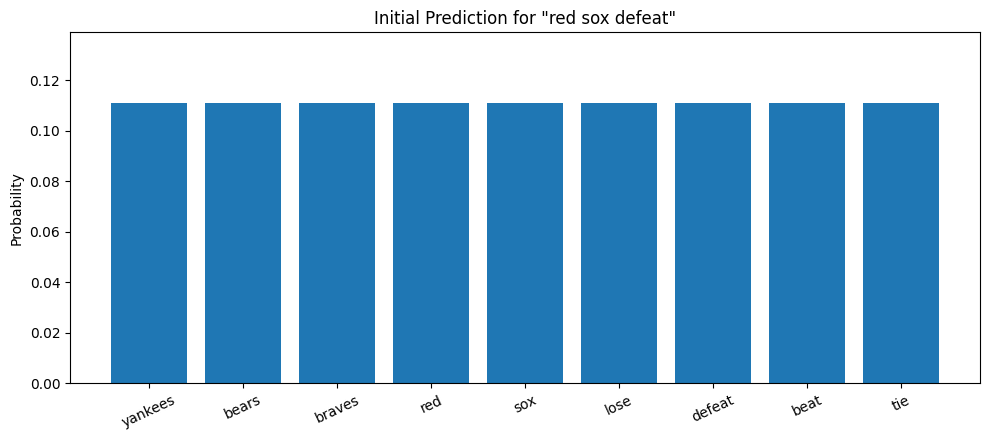

In [11]:
probs = pred.flatten()
words = list(word_vects.keys())

plt.figure(figsize=(10, 4.5))
plt.bar(words, probs)
plt.ylim(0, max(probs)*1.25)
plt.ylabel("Probability")
plt.title('Initial Prediction for "red sox defeat"')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Karena seluruh `word_vects` di source masih berupa vector nol, sentence embedding juga belum mengandung informasi. Akibatnya prediction awal untuk 9 words menjadi uniform, masing-masing sekitar `1/9`. Ini adalah **initial state**, bukan performa network setelah training.

## Forward Propagation with Arbitrary Length

Ketika sequence memiliki panjang arbitrer, jumlah forward steps juga berubah.

Source menggunakan list `layers` untuk menyimpan state pada setiap timestep. Pada setiap step:

1. predict next word dari hidden state sebelumnya;
2. hitung loss;
3. generate hidden state berikutnya menggunakan `recurrent` dan word embedding.

Secara ringkas:

`hidden_t = hidden_(t-1) × recurrent + embed[word_t]`

`prediction_t = softmax(hidden_(t-1) × decoder)`

Pendekatan ini memungkinkan jumlah timestep mengikuti panjang sentence.

In [12]:
# Implementasi predict() mengikuti struktur source.
def predict(sent, start, recurrent, embed, decoder):
    layers = []
    layer = {}
    layer["hidden"] = start
    layers.append(layer)

    loss = 0
    for target_i in range(len(sent)):
        layer = {}
        layer["pred"] = softmax(layers[-1]["hidden"].dot(decoder))
        loss += -np.log(layer["pred"][sent[target_i]])
        layer["hidden"] = (
            layers[-1]["hidden"].dot(recurrent) +
            embed[sent[target_i]]
        )
        layers.append(layer)

    return layers, loss

print("predict() follows the variable-length forward propagation structure.")

predict() follows the variable-length forward propagation structure.


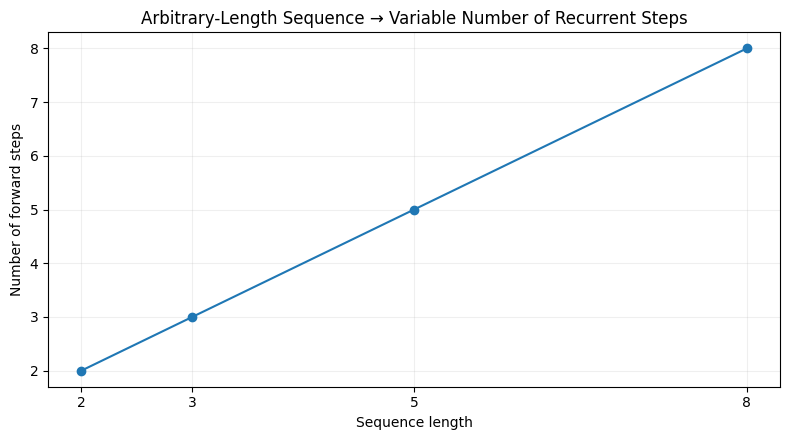

In [13]:
# Demonstrasi jumlah timestep berubah mengikuti panjang input.
lengths = [2, 3, 5, 8]

plt.figure(figsize=(8, 4.5))
plt.plot(lengths, lengths, marker="o")
plt.xlabel("Sequence length")
plt.ylabel("Number of forward steps")
plt.title("Arbitrary-Length Sequence → Variable Number of Recurrent Steps")
plt.xticks(lengths)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Backpropagation with Arbitrary Length

Backpropagation tetap mengikuti prinsip yang sama seperti chapter sebelumnya, tetapi sekarang gradient harus melewati beberapa timestep.

Source melakukan loop dari layer terakhir menuju layer pertama:

`for layer_idx in reversed(range(len(layers)))`

Pada setiap step, output gradient diteruskan kembali melalui `decoder`, lalu hidden gradient dari timestep berikutnya juga ikut berkontribusi melalui `recurrent`.

Ini adalah bentuk dasar dari **Backpropagation Through Time (BPTT)**, walaupun istilah tersebut menjadi lebih eksplisit pada pembahasan lanjutan.

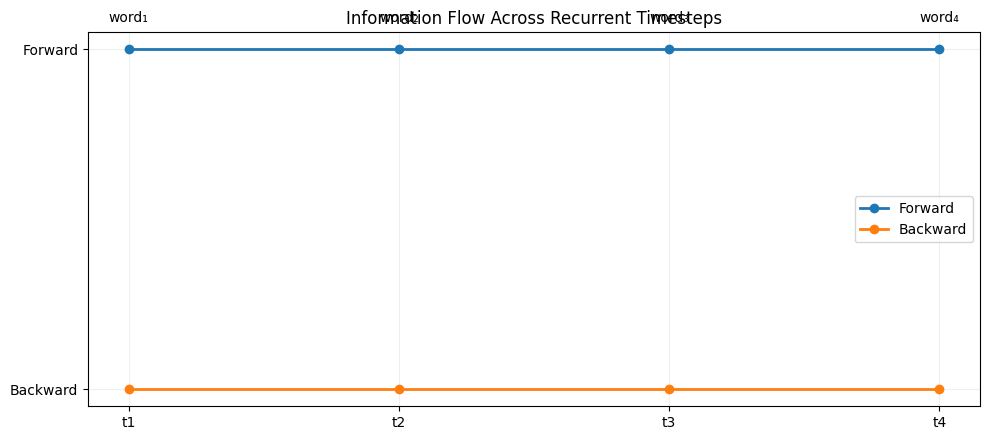

In [14]:
# Ilustrasi aliran forward dan backward pada sequence.
words = ["word₁", "word₂", "word₃", "word₄"]
x = np.arange(len(words))

plt.figure(figsize=(10, 4.5))
plt.plot(x, np.ones(len(x)), marker="o", linewidth=2, label="Forward")
plt.plot(x, np.zeros(len(x)), marker="o", linewidth=2, label="Backward")
for i, word in enumerate(words):
    plt.text(i, 1.08, word, ha="center")
plt.yticks([0,1], ["Backward", "Forward"])
plt.xticks(x, ["t1","t2","t3","t4"])
plt.title("Information Flow Across Recurrent Timesteps")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Weight Update with Arbitrary Length

Setelah gradient diperoleh, source memperbarui:
- `start`
- `decoder`
- `embed`
- `recurrent`

Learning rate yang digunakan source adalah:

`alpha = 0.001`

dan training dilakukan selama:

`30000 iterations`

Update dibagi dengan panjang sentence agar kontribusi sequence dinormalisasi berdasarkan jumlah timestep.

In [15]:
# Source configuration yang relevan untuk training.
config = {
    "iterations": 30000,
    "alpha": 0.001,
    "embed_size": 10
}

for k, v in config.items():
    print(f"{k}: {v}")

iterations: 30000
alpha: 0.001
embed_size: 10


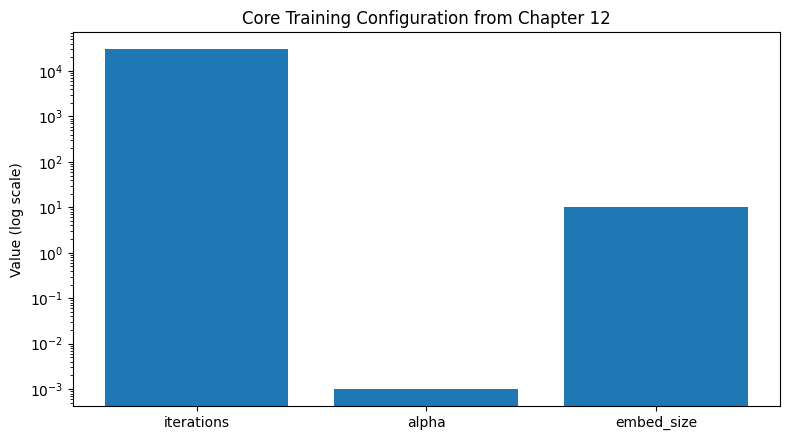

In [16]:
plt.figure(figsize=(8, 4.5))
plt.bar(config.keys(), config.values())
plt.yscale("log")
plt.ylabel("Value (log scale)")
plt.title("Core Training Configuration from Chapter 12")
plt.tight_layout()
plt.show()

## Execution and Output Analysis: Perplexity

Metric utama yang dibahas pada akhir training adalah **perplexity**.

Secara konseptual:
- perplexity tinggi → predicted probability distribution jauh dari target;
- perplexity rendah → distribution semakin dekat;
- nilai yang mendekati `1` berarti prediction distribution semakin mendekati target.

Source melaporkan trend:

`82.0923 → 81.8762 → 81.5371 → ... → 4.1326 → 4.0717 → 4.0168`

Artinya network semakin baik dalam memodelkan probability distribution untuk next-word prediction.

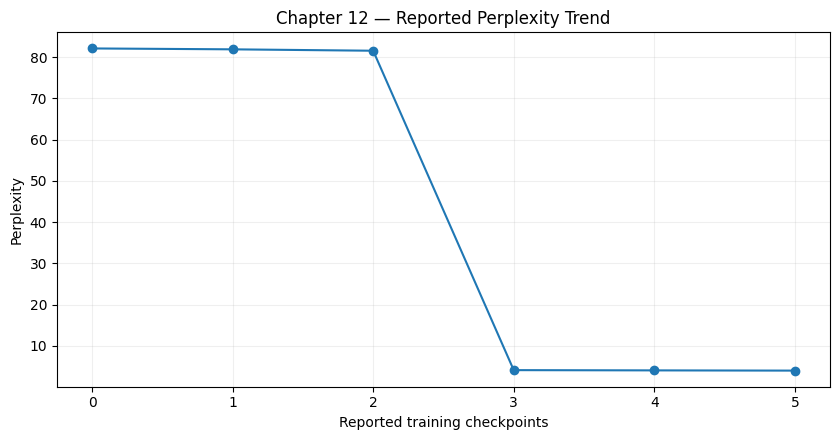

In [17]:
# Source-reported checkpoints.
steps = [0, 1, 2, 3, 4, 5]
perplexity = [
    82.09227500075585,
    81.87615610433569,
    81.53705034457951,
    4.132556753967558,
    4.071667181580819,
    4.016781447371843
]

plt.figure(figsize=(8.5, 4.5))
plt.plot(steps, perplexity, marker="o")
plt.xlabel("Reported training checkpoints")
plt.ylabel("Perplexity")
plt.title("Chapter 12 — Reported Perplexity Trend")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Catatan akurasi:** source hanya menampilkan beberapa checkpoint dan tanda `....` di antaranya. Karena itu chart di atas menghubungkan checkpoint yang dilaporkan sebagai visualisasi ringkas; titik di tengah tidak diklaim sebagai output source.

## Looking at Predictions

Buku kemudian menyarankan melihat prediction secara langsung karena perplexity saja tidak menjelaskan **apa yang sebenarnya dipelajari network**.

Source menggunakan sentence:

`['sandra', 'moved', 'to', 'the', 'garden.']`

dan membandingkan:
- previous input;
- true next word;
- predicted word.

Setelah training awal, prediction masih banyak salah. Dengan training lebih lanjut, prediction mulai berubah.

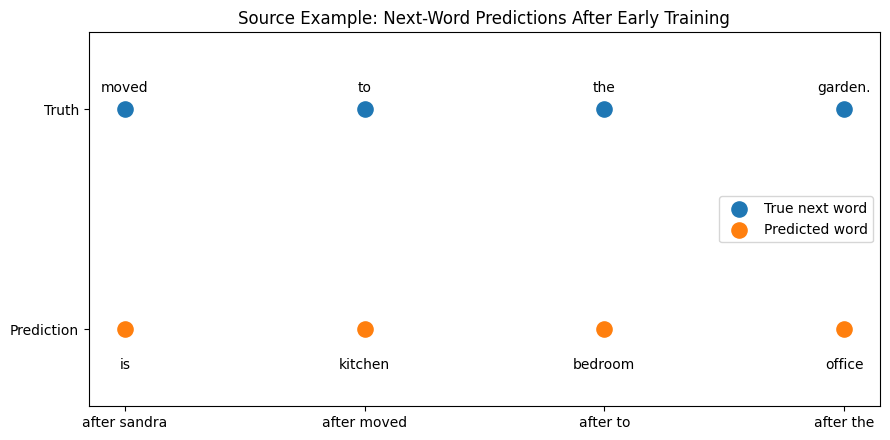

In [18]:
# Source-reported example after 100 training steps.
true_words = ["moved", "to", "the", "garden."]
pred_words = ["is", "kitchen", "bedroom", "office"]

x = np.arange(len(true_words))
plt.figure(figsize=(9, 4.5))
plt.scatter(x, [1]*len(x), s=120, label="True next word")
plt.scatter(x, [0]*len(x), s=120, label="Predicted word")

for i, word in enumerate(true_words):
    plt.text(i, 1.08, word, ha="center")
for i, word in enumerate(pred_words):
    plt.text(i, -0.18, word, ha="center")

plt.yticks([0,1], ["Prediction", "Truth"])
plt.xticks(x, ["after sandra","after moved","after to","after the"])
plt.title("Source Example: Next-Word Predictions After Early Training")
plt.legend()
plt.ylim(-0.35, 1.35)
plt.tight_layout()
plt.show()

Visual ini bukan confusion matrix karena source tidak menyediakan keseluruhan vocabulary prediction. Visual hanya memetakan pasangan **true vs predicted word** dari contoh yang diberikan buku.

## Core Idea: Recurrent Layer

Inti Chapter 12 dapat diringkas menjadi:

**Current word + previous hidden state → new hidden state → next-word prediction**

Transition/recurrent matrix yang sama digunakan kembali pada setiap timestep.

Dengan demikian, network tidak hanya melihat kata secara terpisah, tetapi membangun state yang membawa informasi dari sequence sebelumnya. Inilah yang membuat RNN cocok untuk **variable-length sequential data**.

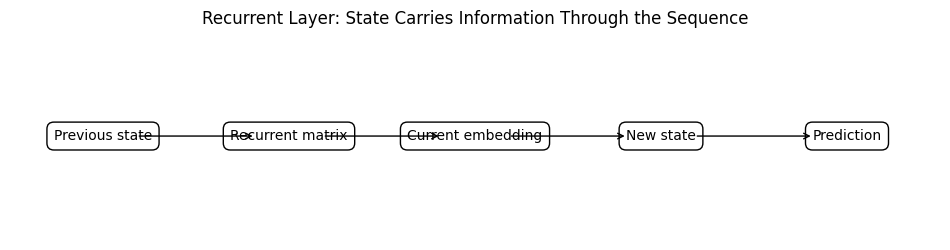

In [19]:
# Ringkasan aliran recurrent computation.
states = ["Previous state", "Recurrent matrix", "Current embedding", "New state", "Prediction"]

plt.figure(figsize=(12, 2.7))
for i, s in enumerate(states):
    plt.text(i, 0.5, s, ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.5", fill=False))
    if i < len(states)-1:
        plt.annotate("", xy=(i+0.82,0.5), xytext=(i+0.18,0.5),
                     arrowprops=dict(arrowstyle="->"))
plt.xlim(-0.5, len(states)-0.5)
plt.ylim(0,1)
plt.axis("off")
plt.title("Recurrent Layer: State Carries Information Through the Sequence")
plt.show()

## Source Code Reproduction: Core RNN Structure

Cell berikut mempertahankan struktur inti source Chapter 12 untuk:
- `softmax`;
- `predict`;
- variable-length layers;
- recurrent state;
- next-word prediction.

Dataset training lengkap tidak disertakan dalam source file notebook ini, sehingga training 30,000 iteration terhadap corpus asli tidak dijalankan ulang di sini.

In [20]:
import numpy as np

def softmax_source(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

def words2indices(sentence, word2index):
    idx = list()
    for word in sentence:
        idx.append(word2index[word])
    return idx

# Source initialization pattern.
np.random.seed(1)
embed_size = 10

# These matrices require a real vocabulary to allocate their full shapes.
# embed = (np.random.rand(len(vocab),embed_size) - 0.5) * 0.1
# recurrent = np.eye(embed_size)
# start = np.zeros(embed_size)
# decoder = (np.random.rand(embed_size, len(vocab)) - 0.5) * 0.1
# one_hot = np.eye(len(vocab))

print("Core Chapter 12 initialization structure reproduced.")

Core Chapter 12 initialization structure reproduced.


## Concept Check

| Pertanyaan | Jawaban inti |
|---|---|
| Apa masalah concatenation? | Panjang sentence berbeda menghasilkan vector dengan panjang berbeda. |
| Mengapa average word vectors menarik? | Semua sentence menghasilkan vector dengan panjang sama dan sentence yang mirip cenderung dekat. |
| Apa kelemahan averaging? | Word order hilang. |
| Mengapa identity matrix digunakan? | Sebagai langkah awal untuk menunjukkan operasi yang mempertahankan vector. |
| Mengapa identity matrix kemudian dipelajari? | Agar transition dapat mengubah representation berdasarkan sequence order. |
| Apa yang diprediksi RNN pada chapter ini? | Next word pada sequence. |
| Mengapa `recurrent` digunakan berulang? | Agar logic yang dipelajari dapat diterapkan pada setiap transition/timestep. |
| Apa arti perplexity yang menurun? | Probability distribution prediction semakin sesuai dengan data. |

## Key Takeaways

1. **Variable-length data** membutuhkan cara representasi yang menghasilkan ukuran vector yang dapat dibandingkan.
2. Averaging word embeddings adalah baseline sederhana yang ternyata cukup powerful.
3. Averaging kehilangan informasi **word order**.
4. Identity matrix menunjukkan operasi yang tidak mengubah vector.
5. Learnable **transition/recurrent matrix** memungkinkan network memodelkan urutan.
6. RNN membangun hidden state secara bertahap sepanjang sequence.
7. Forward propagation dilakukan pada setiap timestep.
8. Backpropagation harus mengalir melewati timestep-timestep tersebut.
9. Training next-word prediction menghasilkan sentence representation yang berguna.
10. **Perplexity** digunakan untuk mengukur seberapa dekat predicted distribution dengan target distribution.
11. Chapter 12 menjadi dasar penting untuk memahami architecture sequence yang lebih lanjut.

## Chapter Summary

Chapter 12 memperluas konsep word embeddings menjadi **sentence embeddings untuk variable-length sequences**. Concatenation menghasilkan vector dengan panjang berbeda, sedangkan averaging menghasilkan fixed-length vector tetapi kehilangan word order.

Untuk mengatasi keterbatasan tersebut, buku memperkenalkan transition matrix yang awalnya berupa identity matrix lalu dibuat **learnable**. Matrix yang sama digunakan kembali pada setiap transition sehingga network dapat belajar bagaimana informasi dari sequence sebelumnya dibawa ke state berikutnya.

Network kemudian dilatih menggunakan **next-word prediction**. Forward propagation menyimpan state untuk setiap timestep, sedangkan backpropagation dan weight update dilakukan dengan memperhitungkan seluruh sequence. Hasil training dianalisis menggunakan **perplexity** dan contoh prediction secara langsung.

Konsep-konsep ini menjadi fondasi untuk memahami recurrent architecture yang lebih kompleks pada chapter berikutnya.

## Reference

Trask, A. W. (2019). *Grokking Deep Learning*. Manning Publications.

Notebook ini mengikuti organization, terminology, code structure, dan reported outputs dari Chapter 12. Visual tambahan diberi berdasarkan kebutuhan konsep/output; visual yang menggunakan angka source diberi penanda sebagai **source-reported**, sedangkan contoh ilustratif tidak diklaim sebagai hasil eksperimen buku.